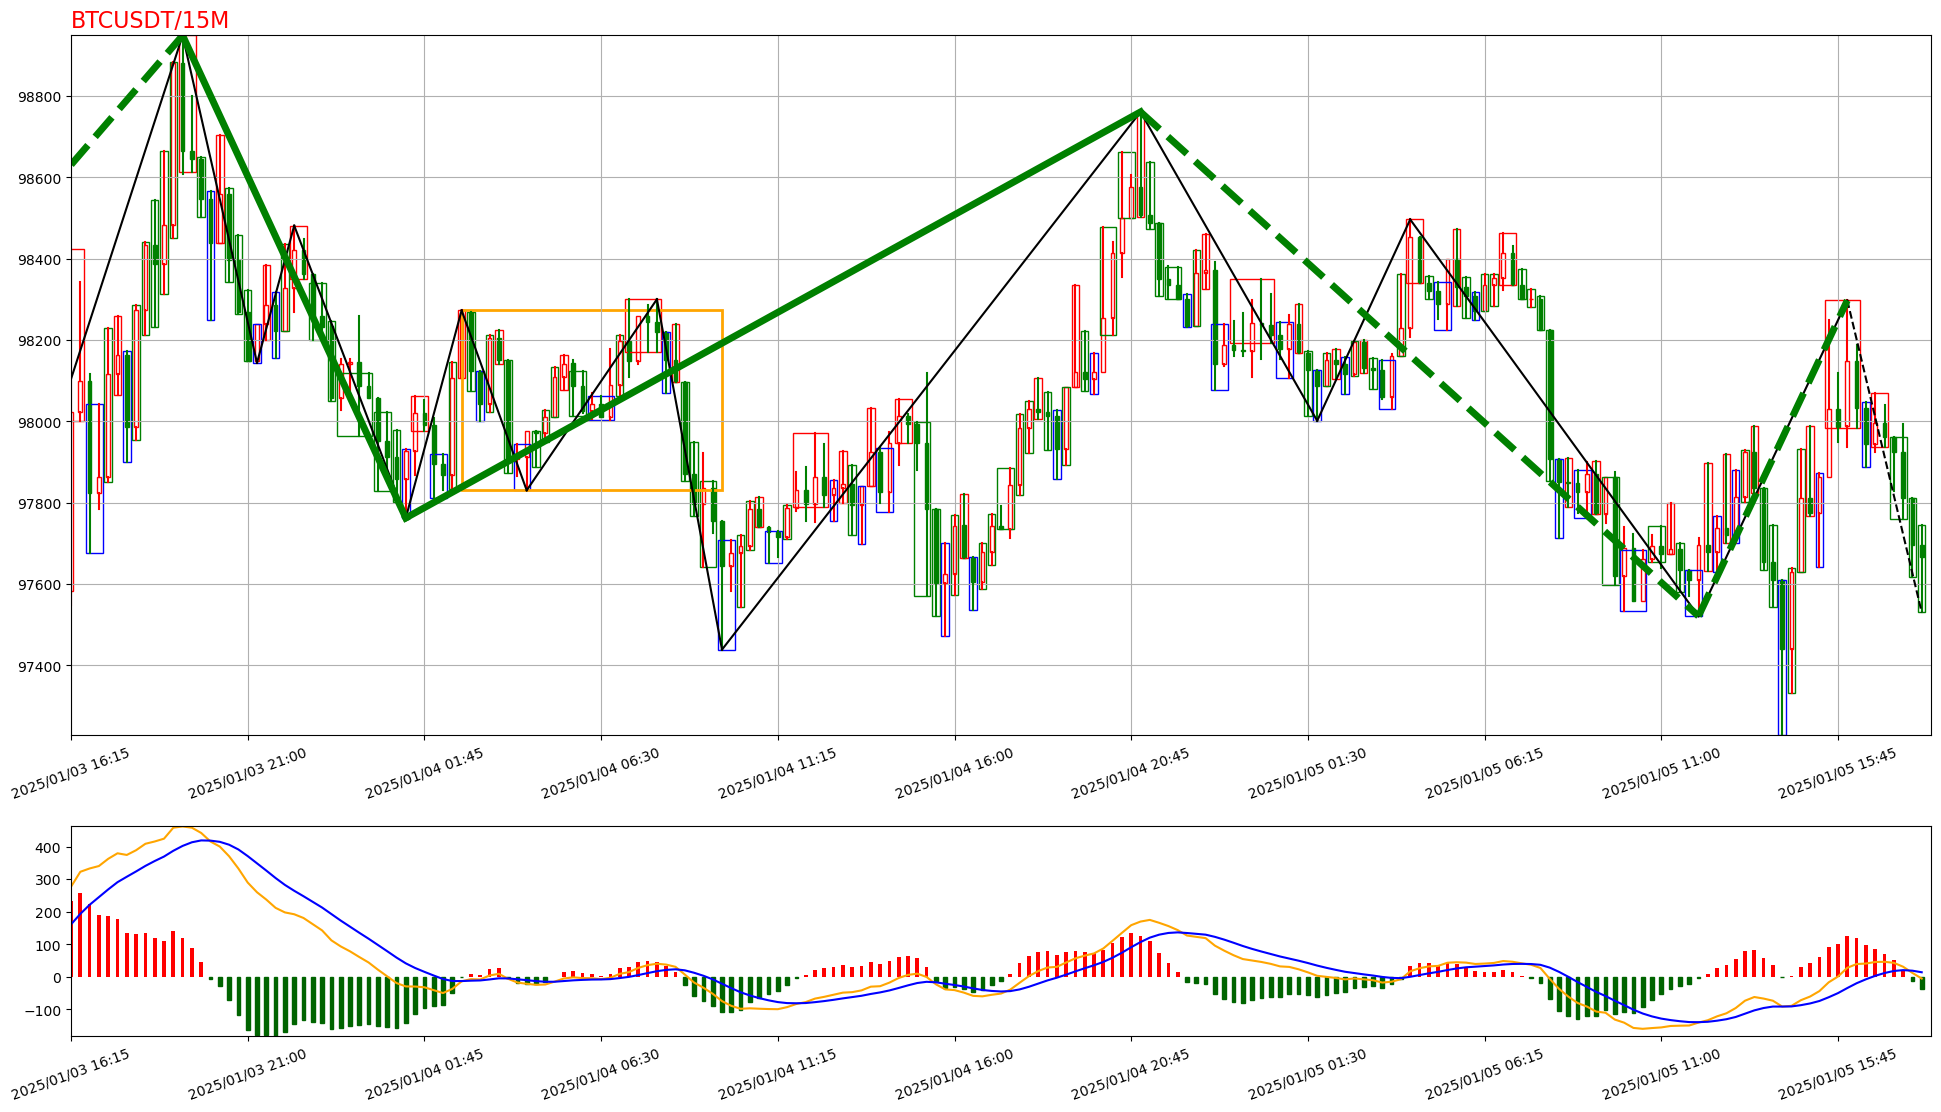

In [ ]:
# %load test1.py

# ===== 必须放在最前面 =====
import sys
import os

project_root = os.path.abspath("..")  # Debug 的上一级

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root:", project_root)

# ===== 再 import =====
from Chan import CChan
from ChanConfig import CChanConfig
from Common.CEnum import AUTYPE, BSP_TYPE, DATA_SRC, FX_TYPE, KL_TYPE
from Plot.AnimatePlotDriver import CAnimateDriver
from Plot.PlotDriver import CPlotDriver
"""
示例策略（回测演示）：
- 演示如何使用 `CChan` 按步触发或逐根喂入 K 线并实现简单交易逻辑。
- 仅为教学示例，不构成投资建议。
"""



if __name__ == "__main__":
    # 简单示例策略：只交易一类买卖点（底分型开仓，顶分型平仓）
    # 该脚本用于回测演示，逻辑保持简洁清晰。
    # 与 main.py 保持一致，使用 CCXT 获取合约/交易对数据（示例使用 BTC/USDT）
    code = "BTCUSDT"
    begin_time = "2025-01-01"
    end_time = "2026-02-04"
    data_src = DATA_SRC.CSV
    lv_list = [KL_TYPE.K_15M]

    # CChan 配置：开启 step 触发并设置分歧率与最小中枢数
    config = CChanConfig({
        "trigger_step": True,
        "divergence_rate": 0.8,
        "min_zs_cnt": 1,
    })

    # 绘图开关：按需开启或关闭各类子图
    plot_config = {
        "plot_kline": True,
        "plot_kline_combine": True,
        "plot_bi": True,
        "plot_seg": True,
        "plot_eigen": False,
        "plot_zs": True,
        "plot_macd": True,
        "plot_mean": False,
        "plot_channel": False,
        "plot_bsp": True,
        "plot_extrainfo": False,
        "plot_demark": False,
        "plot_marker": False,
        "plot_rsi": False,
        "plot_kdj": False,
    }

    # 绘图参数：局部绘制参数和图像范围
    plot_para = {
        "seg": {},
        "bi": {},
        "figure": {"x_range": 200},
        "marker": {},
    }


    # 初始化 CChan（自动加载历史数据并开始计算）
    chan = CChan(
        code=code,
        begin_time=begin_time,
        end_time=end_time,
        data_src=data_src,
        lv_list=lv_list,
        config=config,
        autype=AUTYPE.NONE,  # 合约/CCXT 数据无需复权
    )

    is_hold = False
    last_buy_price = None
    # 遍历按步返回的快照（每增加一根 K 线会产出新的静态计算结果）
    for chan_snapshot in chan.step_load():
        # 获取最新的买卖点列表（按时间倒序）
        bsp_list = chan_snapshot.get_latest_bsp()
        if not bsp_list:
            continue
        last_bsp = bsp_list[0]
        # 仅处理 T1 / T1P 类型买卖点
        if BSP_TYPE.T1 not in last_bsp.type and BSP_TYPE.T1P not in last_bsp.type:
            continue
        cur_lv_chan = chan_snapshot[0]
        # 仅当买卖点对应的 K 线与当前倒数第二根 K 线对齐时才执行交易判定
        if last_bsp.klu.klc.idx != cur_lv_chan[-2].idx:
            continue
        # 底分型且为买点且未持仓 → 开仓
        if cur_lv_chan[-2].fx == FX_TYPE.BOTTOM and last_bsp.is_buy and not is_hold:
            last_buy_price = cur_lv_chan[-1][-1].close
            print(f'{cur_lv_chan[-1][-1].time}:buy price = {last_buy_price}')
            is_hold = True
        # 顶分型且为卖点且持仓中 → 平仓
        elif cur_lv_chan[-2].fx == FX_TYPE.TOP and not last_bsp.is_buy and is_hold:
            sell_price = cur_lv_chan[-1][-1].close
            print(f'{cur_lv_chan[-1][-1].time}:sell price = {sell_price}, profit rate = {(sell_price-last_buy_price)/last_buy_price*100:.2f}%')
            is_hold = False

    # 根据是否为动图模式选择静态或动画绘制
    if not config.trigger_step:
        plot_driver = CPlotDriver(chan, plot_config=plot_config, plot_para=plot_para)
        plot_driver.figure.show()          # 在交互环境显示
        plot_driver.save2img("./result/test.png")
    else:
        CAnimateDriver(chan, plot_config=plot_config, plot_para=plot_para)